# Timing: `distorted-greedy` vs. `heap-distorted-greedy`

Loads the results produced by each dataset's `experiments/{dataset}/timer.py` (saved to `data/experiments/{dataset}/timing/exp_timing.json`) and plots number of rules in the candidate pool vs. `PEC.fit()` wall-clock time, one figure per dataset, for both selection algorithms.

Datasets with no `exp_timing.json` yet (because `timer.py` hasn't been run for them) are skipped with a printed notice rather than raising.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
datasets = ['climate', 'mnist']

algorithms = ['distorted-greedy', 'heap-distorted-greedy']
algorithm_labels = {
    'distorted-greedy': 'Distorted Greedy',
    'heap-distorted-greedy': 'Heap Distorted Greedy',
}
algorithm_colors = {
    'distorted-greedy': 'tab:blue',
    'heap-distorted-greedy': 'tab:orange',
}

In [3]:
# Load timing results for every dataset that has been run so far.
timing_results = {}
for dataset in datasets:
    path = f'../data/experiments/{dataset}/timing/exp_timing.json'
    if not os.path.exists(path):
        print(f"Skipping '{dataset}': no timing results found at {path} "
              f"(run experiments/{dataset}/timer.py first).")
        continue
    with open(path) as f:
        timing_results[dataset] = json.load(f)

print(f"Loaded timing results for: {list(timing_results.keys())}")

Loaded timing results for: ['climate', 'mnist']


## Number of rules vs. fit time

One figure per dataset. Points are the mean `PEC.fit()` time across trials at each rule-pool size; error bars are +/- 1 standard deviation across trials.

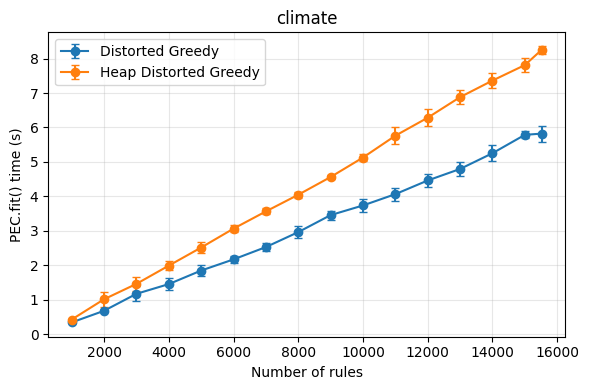

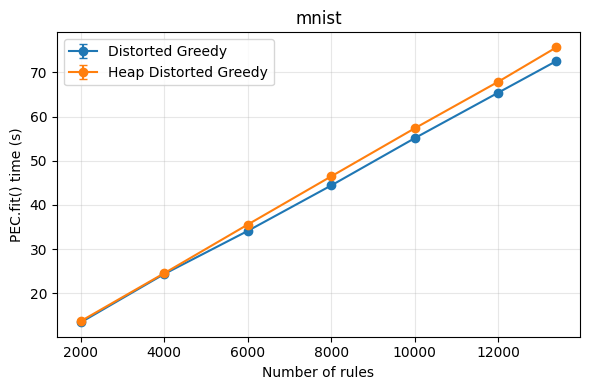

In [4]:
for dataset, results in timing_results.items():
    pool_sizes = results['pool_sizes']

    fig, ax = plt.subplots(figsize=(6, 4))
    for alg in algorithms:
        means = [step['mean'] for step in results[alg]]
        stds = [step['std'] for step in results[alg]]
        ax.errorbar(
            pool_sizes, means, yerr=stds,
            label=algorithm_labels[alg],
            color=algorithm_colors[alg],
            marker='o', capsize=3,
        )

    ax.set_xlabel('Number of rules')
    ax.set_ylabel('PEC.fit() time (s)')
    ax.set_title(dataset)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()